# 7. Builder Comparison

Side-by-side analysis of Shea Homes against three major production homebuilders — KB Home, Lennar, and Pulte Homes — using the same NLP pipeline applied to each builder's customer reviews on NewHomeSource.com.

**Builders analyzed:**
- **Shea Homes** — 2,052 reviews
- **KB Home** — ~11,292 reviews
- **Lennar** — ~20,317 reviews
- **Pulte Homes** — ~15,309 reviews

All reviews share the same schema: title, reviewer name, verified status, date, location, review text, and five rating dimensions (total, quality, trustworthiness, value, responsiveness).

## 7.0 Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import glob
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# NLTK setup
import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob

sia = SentimentIntensityAnalyzer()

In [4]:
# load all builder review files
BUILDER_NAMES = {
    'kb-home': 'KB Home',
    'lennar': 'Lennar',
    'pulte-homes': 'Pulte Homes',
    'shea-homes': 'Shea Homes',
}

BUILDER_COLORS = {
    'Shea Homes': '#1a5276',
    'KB Home': '#c0392b',
    'Lennar': '#27ae60',
    'Pulte Homes': '#8e44ad',
}

frames = []
for path in sorted(glob.glob('../builder_reviews/*_reviews.csv')):
    slug = os.path.basename(path).replace('_reviews.csv', '')
    bdf = pd.read_csv(path, encoding='utf-8-sig')
    bdf['builder'] = BUILDER_NAMES.get(slug, slug)
    frames.append(bdf)

df = pd.concat(frames, ignore_index=True)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))
df['state'] = df['location'].str.extract(r',\s*([A-Z]{2})$')
df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.to_period('Q').astype(str)

# Sentiment scores
scores = df['review_text'].apply(lambda x: sia.polarity_scores(str(x)))
df['vader_compound'] = scores.apply(lambda x: x['compound'])
df['vader_label'] = df['vader_compound'].apply(
    lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
)
df['risk_class'] = df['total_score'].apply(
    lambda x: 'Satisfied (4-5)' if x >= 4 else 'At-Risk (1-3)'
)

print(f'Total reviews loaded: {len(df):,}')
df.groupby('builder').size().sort_values(ascending=False)

Total reviews loaded: 48,814


builder
Lennar         20216
Pulte Homes    15256
KB Home        11290
Shea Homes      2052
dtype: int64

## 7.1 Overall Ratings

In [6]:
summary = df.groupby('builder').agg(
    reviews=('total_score', 'size'),
    avg_rating=('total_score', 'mean'),
    median_rating=('total_score', 'median'),
    pct_5_star=('total_score', lambda x: (x == 5).mean() * 100),
    pct_at_risk=('total_score', lambda x: (x <= 3).mean() * 100),
).round(2).sort_values('avg_rating', ascending=False)

summary

,reviews,avg_rating,median_rating,pct_5_star,pct_at_risk
builder,,,,,
KB Home,11290,4.46,5.0,71.79,14.53
Shea Homes,2052,4.21,5.0,56.73,22.03
Pulte Homes,15256,3.91,4.0,48.09,31.68
Lennar,20216,3.67,4.0,41.65,39.65


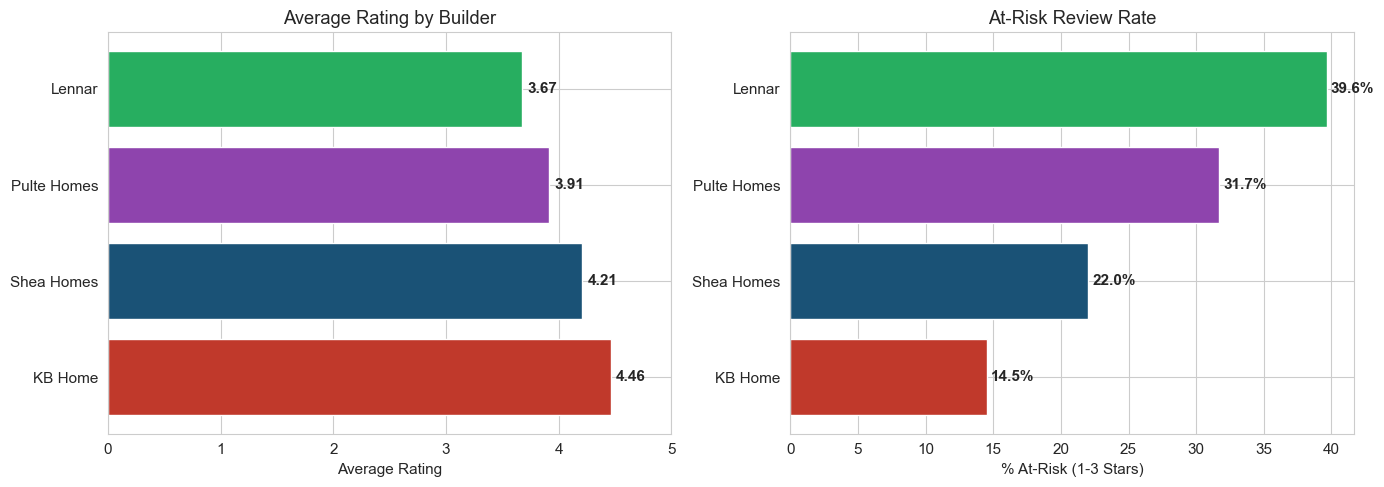

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# avg rating bar chart
order = summary.index.tolist()
colors = [BUILDER_COLORS[b] for b in order]
axes[0].barh(order, summary['avg_rating'], color=colors)
axes[0].set_xlim(0, 5)
axes[0].set_xlabel('Average Rating')
axes[0].set_title('Average Rating by Builder')
for i, v in enumerate(summary['avg_rating']):
    axes[0].text(v + 0.05, i, f'{v:.2f}', va='center', fontweight='bold')

# At-risk percentage
axes[1].barh(order, summary['pct_at_risk'], color=colors)
axes[1].set_xlabel('% At-Risk (1-3 Stars)')
axes[1].set_title('At-Risk Review Rate')
for i, v in enumerate(summary['pct_at_risk']):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7.2 Star Rating Distribution

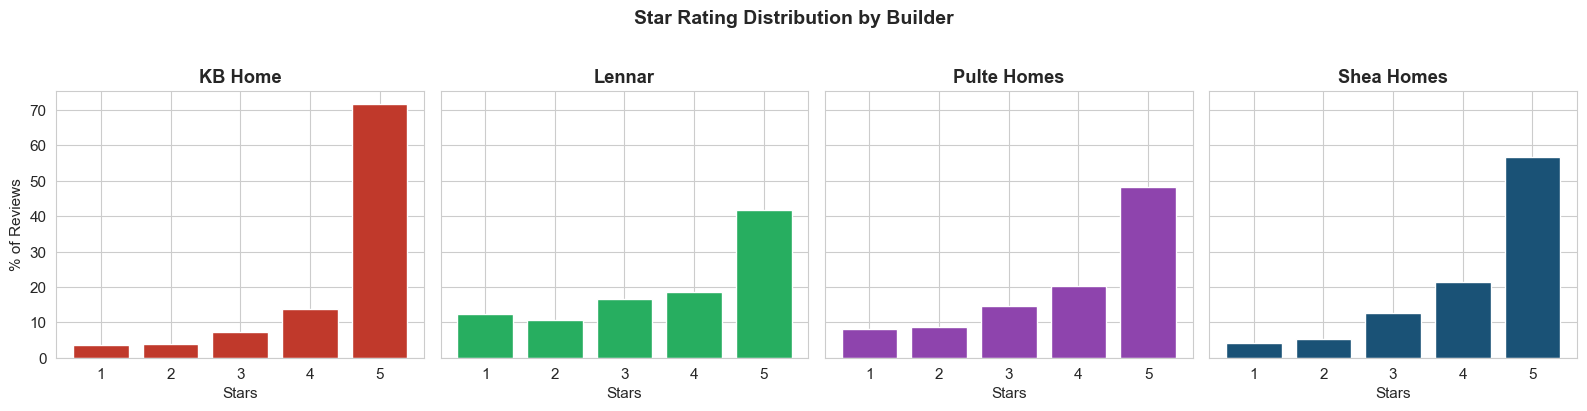

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, builder in zip(axes, sorted(BUILDER_COLORS.keys())):
    bslice = df[df['builder'] == builder]
    dist = bslice['total_score'].value_counts(normalize=True).sort_index() * 100
    ax.bar(dist.index, dist.values, color=BUILDER_COLORS[builder])
    ax.set_title(builder, fontweight='bold')
    ax.set_xlabel('Stars')
    ax.set_xticks([1, 2, 3, 4, 5])
    if ax == axes[0]:
        ax.set_ylabel('% of Reviews')

plt.suptitle('Star Rating Distribution by Builder', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7.3 Rating Dimensions

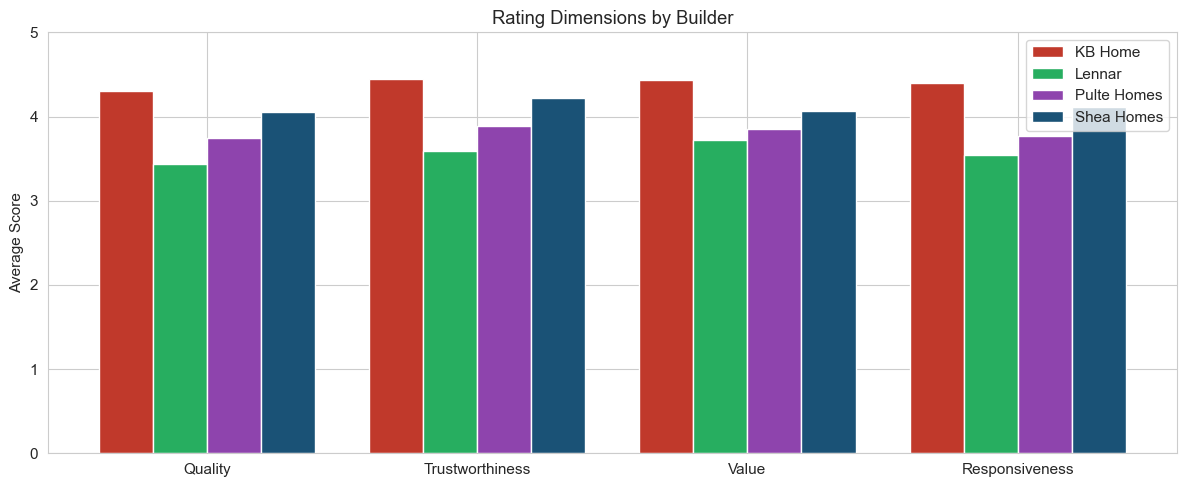

builder,KB Home,Lennar,Pulte Homes,Shea Homes
quality,4.30,3.43,3.74,4.06
trustworthiness,4.45,3.59,3.89,4.21
value,4.44,3.72,3.85,4.06
responsiveness,4.40,3.55,3.76,4.12


In [11]:
dims = ['quality', 'trustworthiness', 'value', 'responsiveness']
dim_means = df.groupby('builder')[dims].mean()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(dims))
width = 0.2

for i, builder in enumerate(sorted(BUILDER_COLORS.keys())):
    vals = dim_means.loc[builder]
    ax.bar(x + i * width, vals, width, label=builder, color=BUILDER_COLORS[builder])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([d.title() for d in dims])
ax.set_ylim(0, 5)
ax.set_ylabel('Average Score')
ax.set_title('Rating Dimensions by Builder')
ax.legend()
plt.tight_layout()
plt.show()

dim_means.round(2).T

## 7.4 Sentiment Comparison

In [13]:
sent_summary = df.groupby('builder').agg(
    avg_vader=('vader_compound', 'mean'),
    pct_positive=('vader_label', lambda x: (x == 'Positive').mean() * 100),
    pct_neutral=('vader_label', lambda x: (x == 'Neutral').mean() * 100),
    pct_negative=('vader_label', lambda x: (x == 'Negative').mean() * 100),
).round(2).sort_values('avg_vader', ascending=False)

sent_summary

,avg_vader,pct_positive,pct_neutral,pct_negative
builder,,,,
KB Home,0.54,82.54,6.47,10.98
Shea Homes,0.50,78.51,5.51,15.98
Pulte Homes,0.39,72.04,6.33,21.63
Lennar,0.30,65.75,6.92,27.33


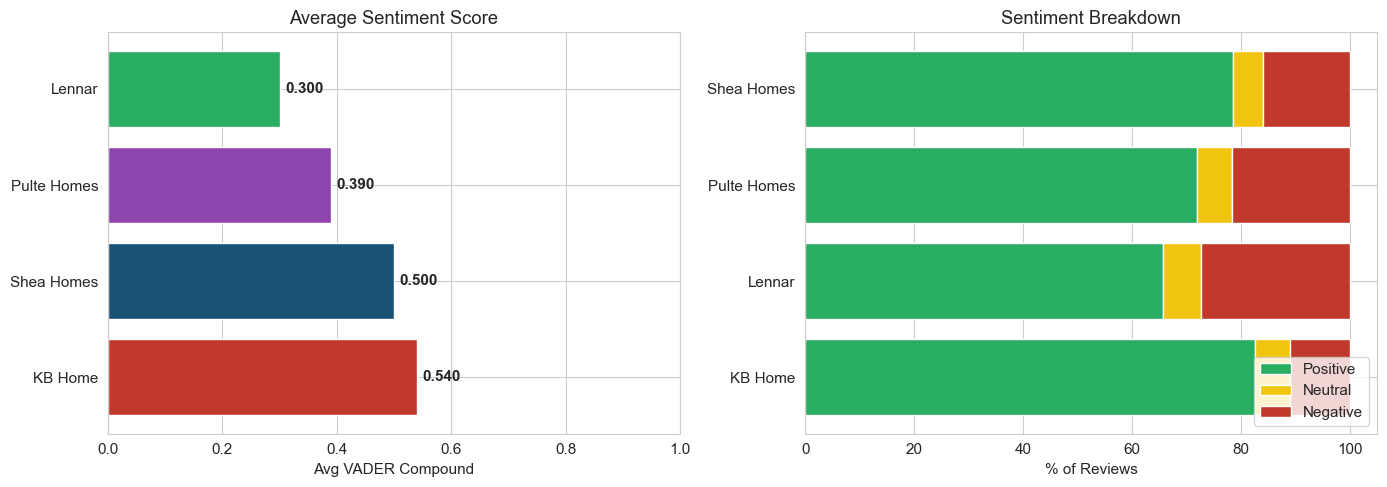

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# avg VADER compound
order = sent_summary.index.tolist()
colors = [BUILDER_COLORS[b] for b in order]
axes[0].barh(order, sent_summary['avg_vader'], color=colors)
axes[0].set_xlim(0, 1)
axes[0].set_xlabel('Avg VADER Compound')
axes[0].set_title('Average Sentiment Score')
for i, v in enumerate(sent_summary['avg_vader']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

# stacked sentiment bars
builders_ordered = sorted(BUILDER_COLORS.keys())
pos = [sent_summary.loc[b, 'pct_positive'] for b in builders_ordered]
neu = [sent_summary.loc[b, 'pct_neutral'] for b in builders_ordered]
neg = [sent_summary.loc[b, 'pct_negative'] for b in builders_ordered]

axes[1].barh(builders_ordered, pos, color='#27ae60', label='Positive')
axes[1].barh(builders_ordered, neu, left=pos, color='#f1c40f', label='Neutral')
axes[1].barh(builders_ordered, neg, left=[p + n for p, n in zip(pos, neu)], color='#c0392b', label='Negative')
axes[1].set_xlabel('% of Reviews')
axes[1].set_title('Sentiment Breakdown')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 7.5 Trends Over Time

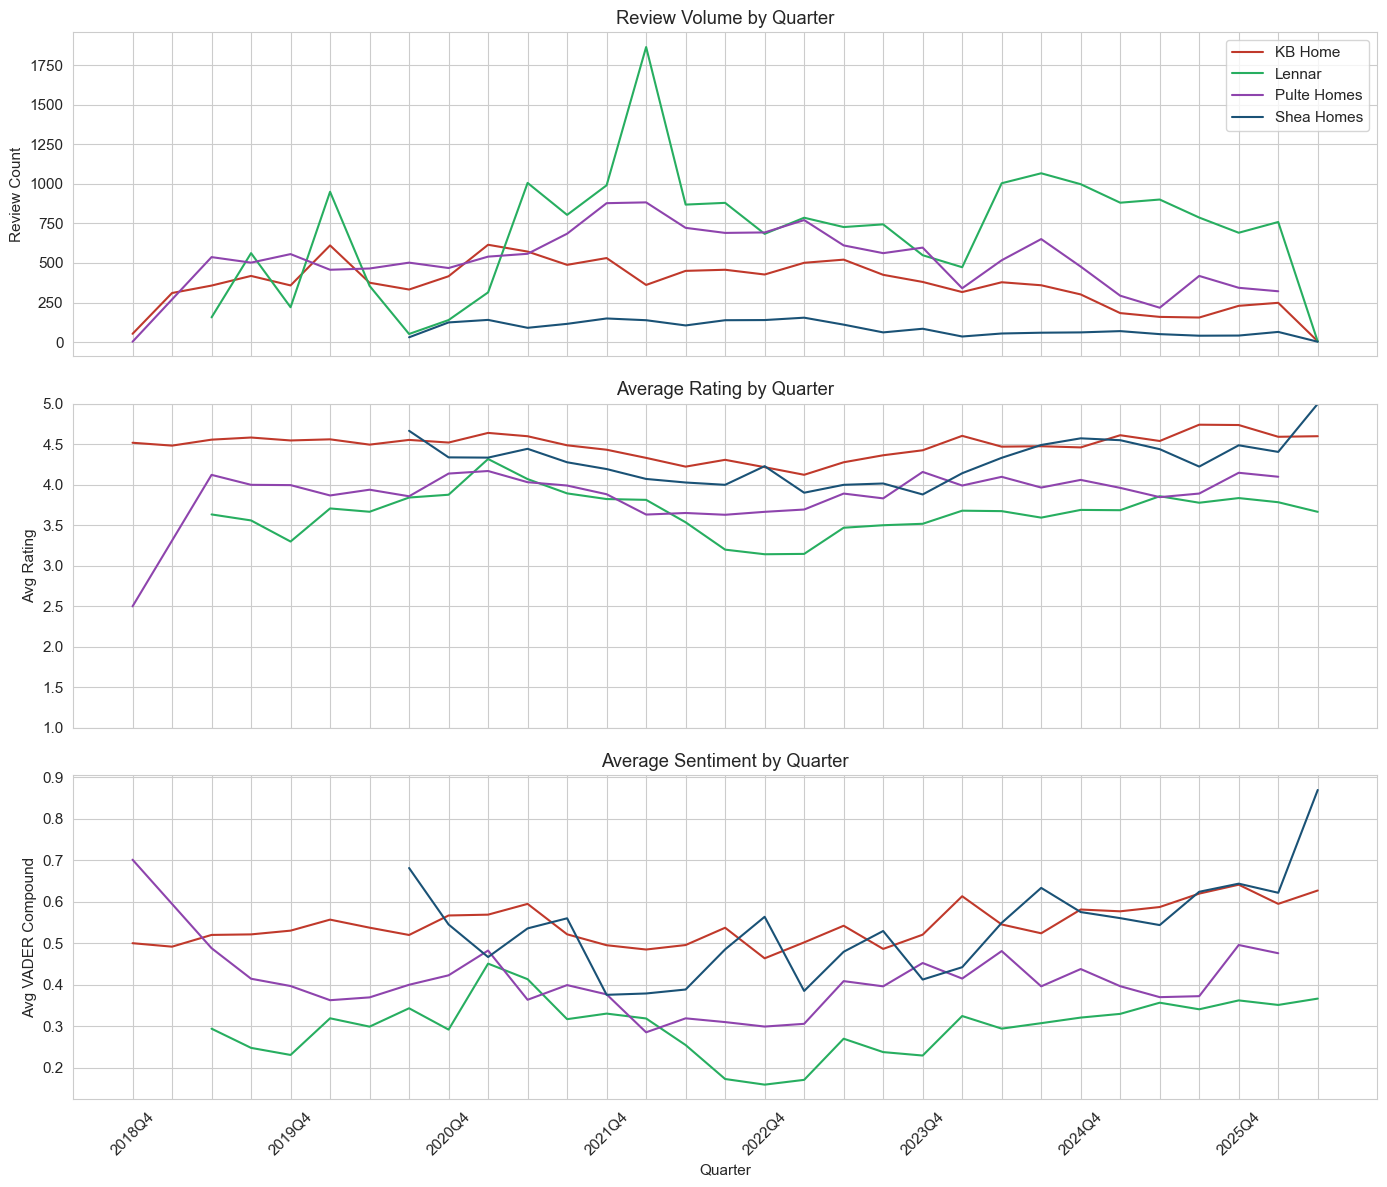

In [16]:
quarterly = df.dropna(subset=['date']).groupby(['quarter', 'builder']).agg(
    reviews=('total_score', 'size'),
    avg_rating=('total_score', 'mean'),
    avg_sentiment=('vader_compound', 'mean'),
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for builder in sorted(BUILDER_COLORS.keys()):
    bq = quarterly[quarterly['builder'] == builder]
    axes[0].plot(bq['quarter'], bq['reviews'], label=builder, color=BUILDER_COLORS[builder], linewidth=1.5)
    axes[1].plot(bq['quarter'], bq['avg_rating'], label=builder, color=BUILDER_COLORS[builder], linewidth=1.5)
    axes[2].plot(bq['quarter'], bq['avg_sentiment'], label=builder, color=BUILDER_COLORS[builder], linewidth=1.5)

axes[0].set_ylabel('Review Count')
axes[0].set_title('Review Volume by Quarter')
axes[0].legend()

axes[1].set_ylabel('Avg Rating')
axes[1].set_title('Average Rating by Quarter')
axes[1].set_ylim(1, 5)

axes[2].set_ylabel('Avg VADER Compound')
axes[2].set_title('Average Sentiment by Quarter')
axes[2].set_xlabel('Quarter')

# Thin out x-axis labels
for ax in axes:
    labels = ax.get_xticklabels()
    for i, label in enumerate(labels):
        if i % 4 != 0:
            label.set_visible(False)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7.6 Geographic Footprint

In [18]:
geo = df.dropna(subset=['state']).groupby(['state', 'builder']).agg(
    reviews=('total_score', 'size'),
    avg_rating=('total_score', 'mean'),
).reset_index()

# which states have multiple builders
state_builders = geo.groupby('state')['builder'].nunique()
shared_states = state_builders[state_builders > 1].index.tolist()

print(f'States with multiple builders: {len(shared_states)}')
print(f'Shared states: {", ".join(sorted(shared_states))}')

# builder footprint
for builder in sorted(BUILDER_COLORS.keys()):
    states = geo[geo['builder'] == builder]['state'].unique()
    print(f'\n{builder}: {len(states)} states — {", ".join(sorted(states))}')

States with multiple builders: 21
Shared states: AZ, CA, CO, FL, GA, ID, IL, IN, MD, MN, NC, NJ, NV, OR, PA, SC, TN, TX, UT, VA, WA

KB Home: 10 states — AZ, CA, CO, FL, ID, NC, NV, SC, TX, WA

Lennar: 26 states — AL, AZ, CA, CO, DE, FL, GA, ID, IL, IN, MD, MN, NC, NJ, NV, OK, OR, PA, SC, TN, TX, UT, VA, WA, WI, WV

Pulte Homes: 26 states — AZ, CA, CO, DC, FL, GA, IL, IN, KY, MA, MD, MI, MN, NC, NJ, NM, NV, OH, OR, PA, SC, TN, TX, UT, VA, WA

Shea Homes: 11 states — AZ, CA, CO, FL, ID, NC, NV, SC, TX, VA, WA


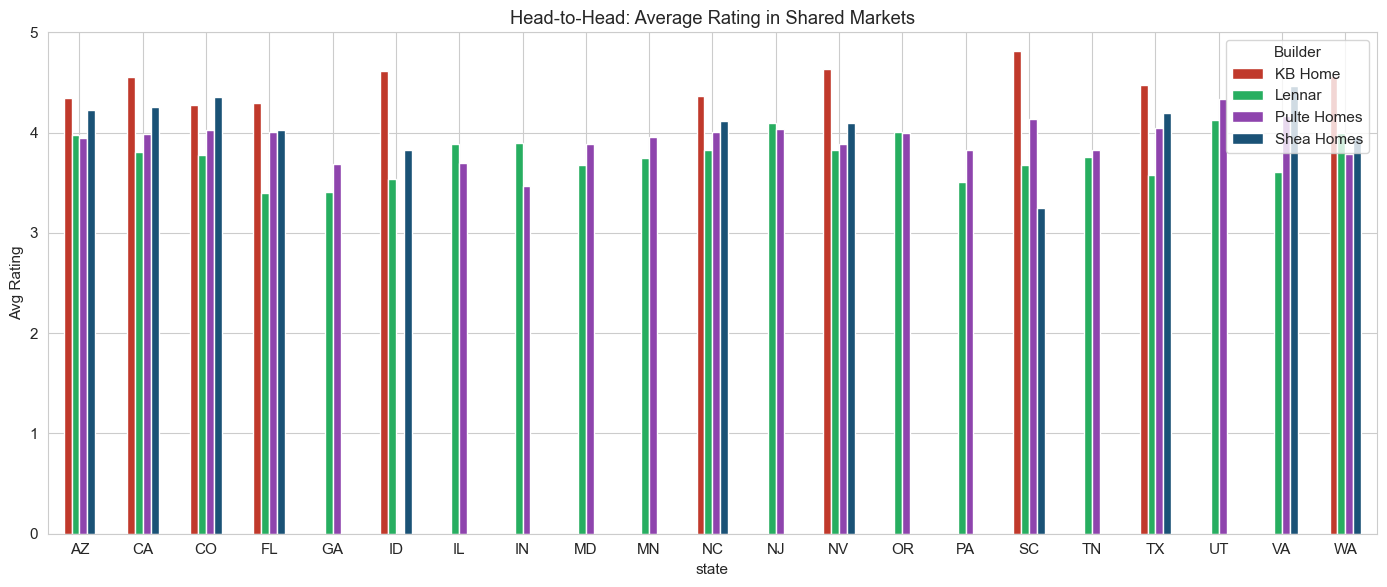

In [19]:
# head-to-head in shared markets
shared = geo[geo['state'].isin(shared_states)].copy()
shared_pivot = shared.pivot_table(index='state', columns='builder', values='avg_rating')

fig, ax = plt.subplots(figsize=(14, 6))
shared_pivot.plot(kind='bar', ax=ax, color=[BUILDER_COLORS.get(c, '#999') for c in shared_pivot.columns])
ax.set_ylim(0, 5)
ax.set_ylabel('Avg Rating')
ax.set_title('Head-to-Head: Average Rating in Shared Markets')
ax.legend(title='Builder')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7.7 Distinctive Language by Builder

Using TF-IDF to identify words that are disproportionately associated with each builder's reviews.

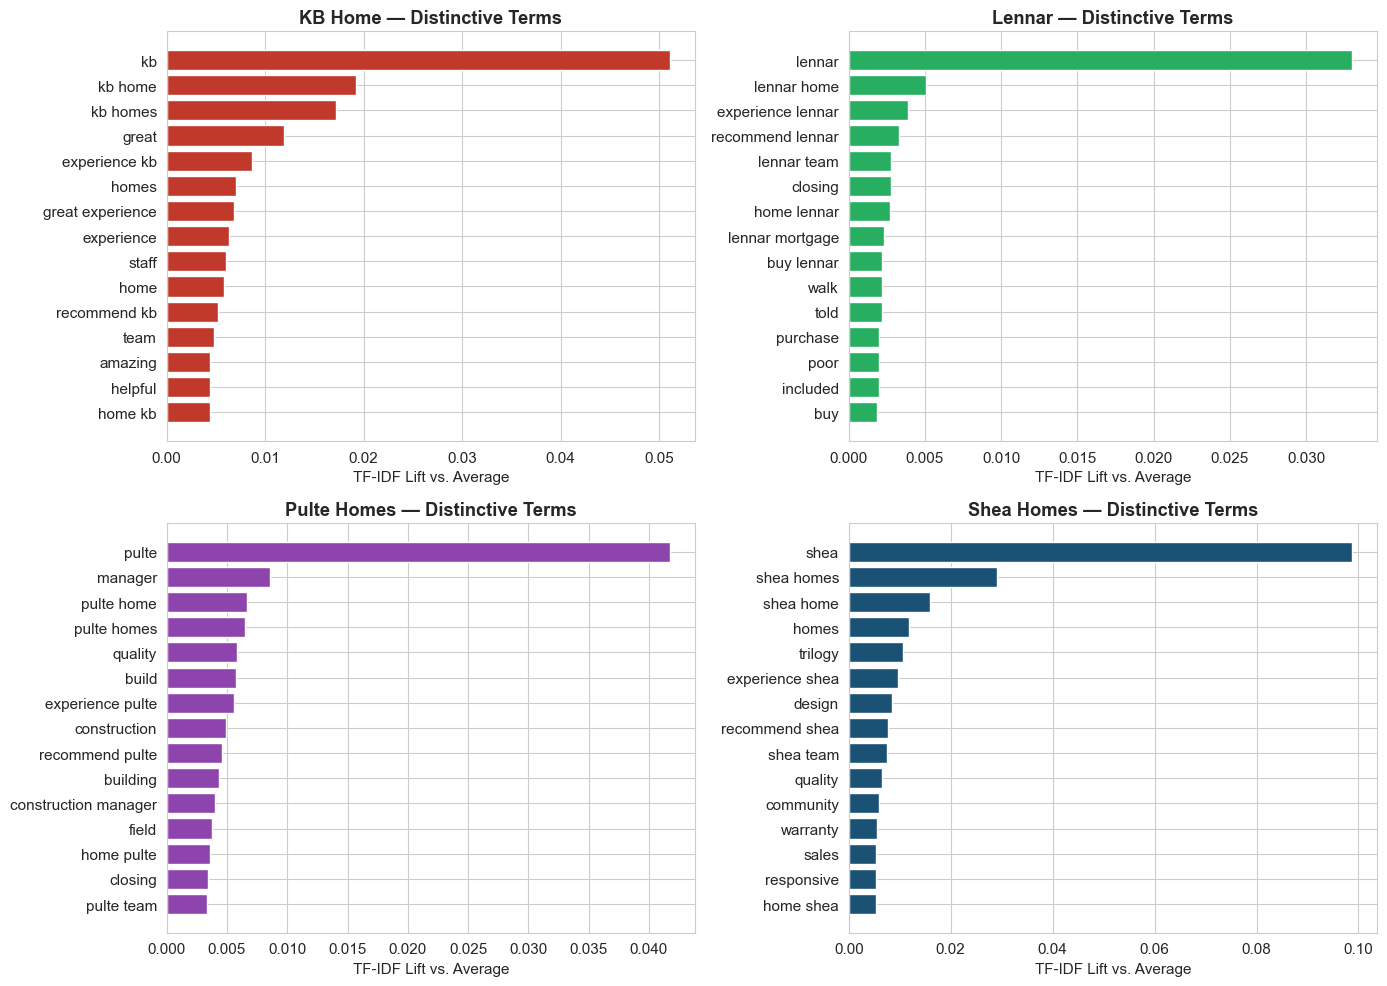

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2),
                         token_pattern=r"(?u)\b\w[\w']+\b")
X = tfidf.fit_transform(df['review_text'].astype(str))
feature_names = tfidf.get_feature_names_out()

# average TF-IDF per builder
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, builder in zip(axes.flat, sorted(BUILDER_COLORS.keys())):
    mask = df['builder'] == builder
    avg_tfidf = X[mask].mean(axis=0).A1
    # subtract overall mean to find distinctive terms
    overall_mean = X.mean(axis=0).A1
    diff = avg_tfidf - overall_mean
    top_idx = diff.argsort()[-15:][::-1]
    words = [feature_names[i] for i in top_idx]
    scores = [diff[i] for i in top_idx]
    
    ax.barh(words[::-1], scores[::-1], color=BUILDER_COLORS[builder])
    ax.set_title(f'{builder} — Distinctive Terms', fontweight='bold')
    ax.set_xlabel('TF-IDF Lift vs. Average')

plt.tight_layout()
plt.show()

## 7.8 Review Length and Engagement

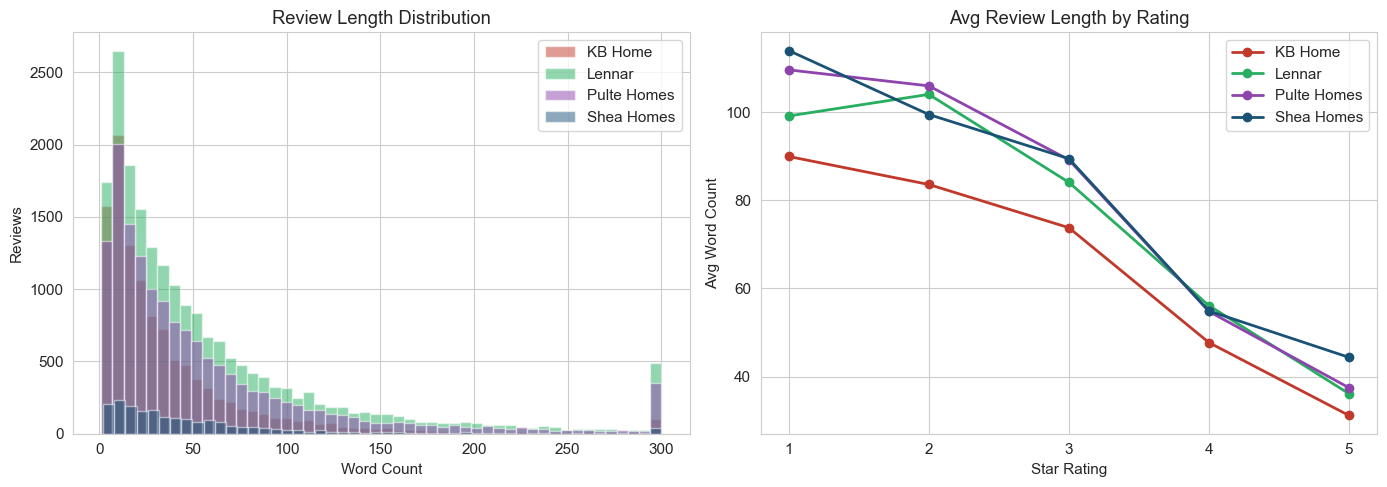

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# word count distribution
for builder in sorted(BUILDER_COLORS.keys()):
    bslice = df[df['builder'] == builder]
    axes[0].hist(bslice['word_count'].clip(upper=300), bins=50, alpha=0.5,
                 label=builder, color=BUILDER_COLORS[builder])

axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Reviews')
axes[0].set_title('Review Length Distribution')
axes[0].legend()

# avg word count by rating
wc_by_rating = df.groupby(['builder', 'total_score'])['word_count'].mean().reset_index()
for builder in sorted(BUILDER_COLORS.keys()):
    bslice = wc_by_rating[wc_by_rating['builder'] == builder]
    axes[1].plot(bslice['total_score'], bslice['word_count'], marker='o',
                 label=builder, color=BUILDER_COLORS[builder], linewidth=2)

axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Avg Word Count')
axes[1].set_title('Avg Review Length by Rating')
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].legend()

plt.tight_layout()
plt.show()

## 7.9 Summary

This comparison provides context for interpreting Shea Homes' performance relative to the broader production homebuilder market. Key takeaways:

1. **Overall positioning**: Where Shea ranks on average rating and at-risk rate vs. competitors
2. **Dimensional strengths**: Which rating dimensions (quality, trust, value, responsiveness) differentiate each builder
3. **Sentiment patterns**: Whether Shea's sentiment profile differs meaningfully from larger-volume builders
4. **Geographic overlap**: Head-to-head performance in shared markets
5. **Language signals**: What topics and phrases are distinctive to each builder's customer base

The full Shea Homes deep-dive (sentiment, topic modeling, predictive classification, LLM analysis) is covered in notebooks 01–06.